In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

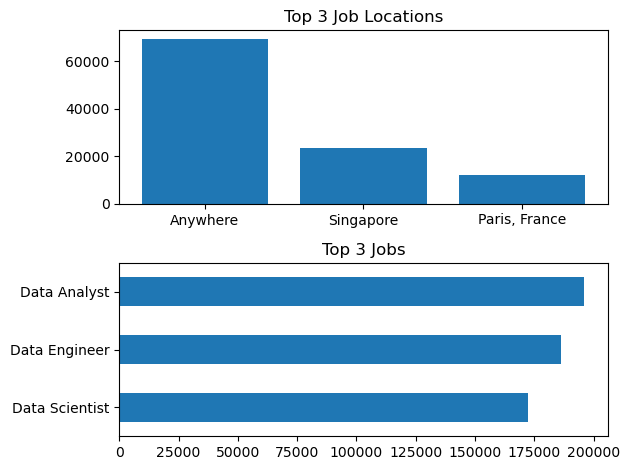

In [ ]:
fig, ax = plt.subplots(2,1)

top3_locations = df['job_location'].value_counts().head(3)
ax[0].bar(top3_locations.index, top3_locations)
ax[0].set_title('Top 3 Job Locations')

top3_jobs = df['job_title_short'].value_counts().head(3)
top3_jobs.plot(kind='barh', ax=ax[1])                                         
ax[1].set_title('Top 3 Jobs')
ax[1].set_ylabel('')
ax[1].invert_yaxis()

fig.tight_layout()

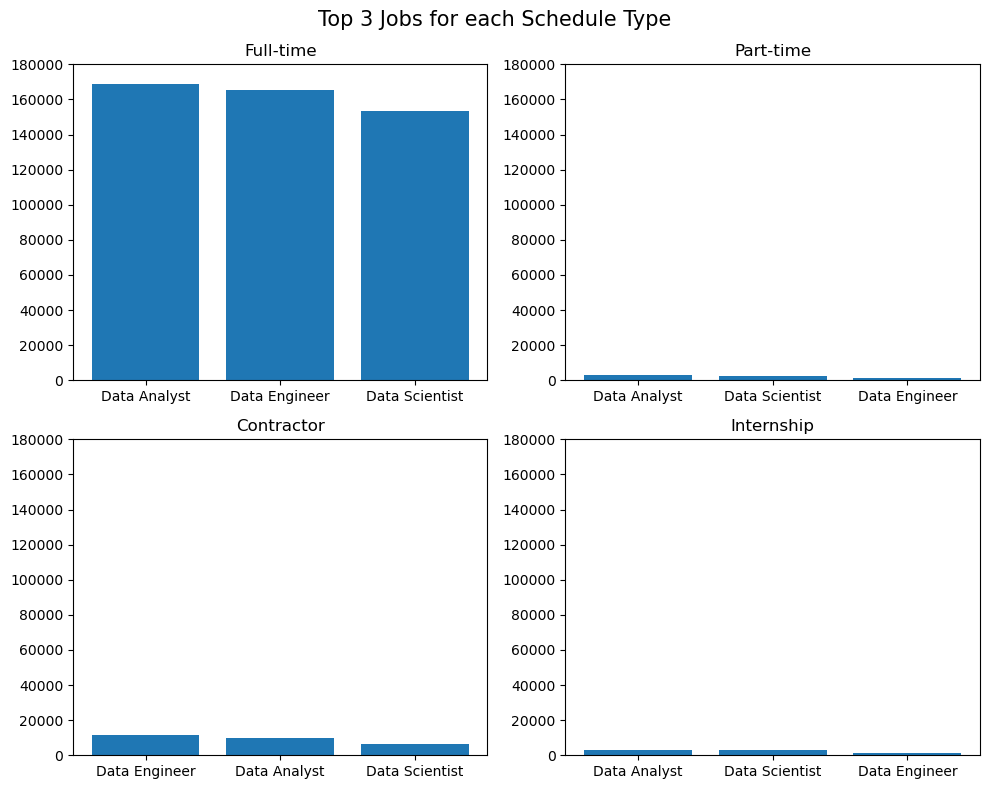

In [73]:
fig, ax = plt.subplots(2,2, figsize=(10,8))
ax = ax.flatten()

schedules = ['Full-time', 'Part-time', 'Contractor', 'Internship']

for i, schedule in enumerate(schedules):
    df_schedule = df[df['job_schedule_type'] == schedule].copy()
    top3_jobs = df_schedule['job_title_short'].value_counts().head(3)
    ax[i].bar(top3_jobs.index, top3_jobs.values)
    ax[i].set_title(schedule)
    ax[i].set_ylim(0, 180000)

fig.suptitle('Top 3 Jobs for each Schedule Type', fontsize=15)
fig.tight_layout()

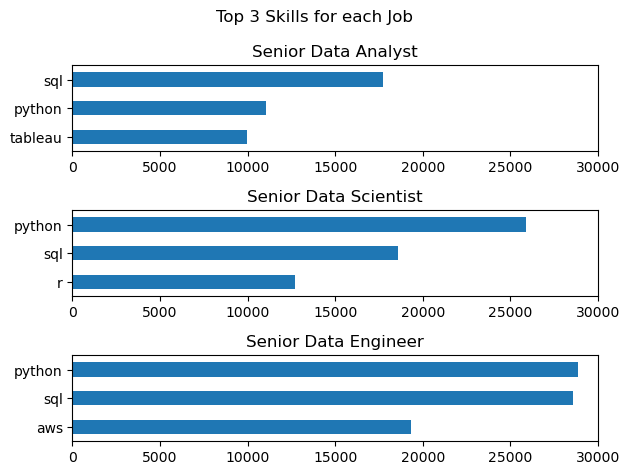

In [ ]:
df_explode = df.copy().explode('job_skills')
jobs_skills = df_explode.groupby(['job_title_short', 'job_skills']).size()
jobs_skills = jobs_skills.sort_values(ascending=False)
jobs_skills = jobs_skills.reset_index(name='skill_count')

job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']

fig, ax = plt.subplots(len(job_roles), 1)

for i, role in enumerate(job_roles):
    top3 = jobs_skills[jobs_skills['job_title_short'] == role].head(3)
    top3.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=role)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('Count')
    ax[i].invert_yaxis()
    ax[i].set_xlim(0, 30000)
    ax[i].legend().set_visible(False)

fig.suptitle('Top 3 Skills for each Job')
fig.tight_layout()